# IEEE-CIS Fraud Detection
**Multimodal credit-card fraud detection on the IEEE-CIS dataset (Kaggle 2019)**

---
## 0 · Problem and Dataset

Vesta Corporation provided ~590 K anonymised e-commerce transactions with a binary fraud label (`isFraud`).  
The class imbalance is severe (~3.5 % fraud), making raw accuracy a misleading metric — a classifier predicting "not fraud" every time scores ~96.5 % accuracy while catching zero fraud cases.  We therefore report **ROC-AUC**, **PR-AUC**, **F1**, **Precision**, **Recall**, and **Recall at 90 % Precision** throughout.

**Data source:** [kaggle.com/competitions/ieee-fraud-detection](https://www.kaggle.com/competitions/ieee-fraud-detection)  
No data is included in this repository.

### Memory note
Free RAM at build time was **~4.5 GB** (below the ~6 GB threshold for the full dataset).  
We therefore use a **50 % stratified random sample (~295 K rows, seed=42)** that preserves the fraud rate.  
The sample is sorted by `TransactionDT` before the time-based split so the temporal ordering is maintained.  
This is documented here, in `reports/metrics.json`, and in the README.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import gc
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns

from src.data     import load_raw, time_split
from src.features import fit_transform, transform
from src.train    import train_all, load_model_store
from src.explain  import (
    shap_analysis, shap_waterfall,
    lime_explanation, permutation_importance_plot,
    plot_roc_pr_curves,
)

sns.set_theme(style='whitegrid', palette='muted')
FIGURES = '../reports/figures'
os.makedirs(FIGURES, exist_ok=True)
print('Setup complete.')

Setup complete.


---
## 1 · Load Data

In [2]:
df = load_raw()   # reads parquet cache if available

print(f'\nDataset shape : {df.shape}')
print(f'Total rows    : {len(df):,}')
print(f'Fraud cases   : {df["isFraud"].sum():,}  ({df["isFraud"].mean():.4%})')
print(f'Columns       : {df.shape[1]}')
df.head(3)

Loading cached parquet: D:\FINAL_PROJECT_v3\ieee-cis-fraud-detection\data\processed\merged_sample.parquet


  Loaded  295,270 rows, 434 cols

Dataset shape : (295270, 434)
Total rows    : 295,270
Fraud cases   : 10,332  (3.4992%)
Columns       : 434


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987006,0,86522,159.0,W,12308,360.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 2 · EDA

In [3]:
# 2a  Fraud rate
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Pie
counts = df['isFraud'].value_counts()
axes[0].pie(counts, labels=['Legitimate', 'Fraud'], autopct='%1.2f%%',
            colors=['#4878CF', '#D65F5F'], startangle=90)
axes[0].set_title('Class Distribution')

# Amount distribution
axes[1].hist(np.log1p(df.loc[df.isFraud==0, 'TransactionAmt']), bins=60,
             alpha=0.6, color='#4878CF', label='Legit')
axes[1].hist(np.log1p(df.loc[df.isFraud==1, 'TransactionAmt']), bins=60,
             alpha=0.6, color='#D65F5F', label='Fraud')
axes[1].set_xlabel('log(1 + TransactionAmt)')
axes[1].set_title('Amount Distribution')
axes[1].legend()

# Fraud over time — use a local variable to avoid mutating df
day_col = df['TransactionDT'] // 86400
daily = df.groupby(day_col)['isFraud'].agg(['sum', 'count'])
daily['rate'] = daily['sum'] / daily['count']
axes[2].plot(daily.index, daily['rate'], lw=1.2, color='#D65F5F')
axes[2].set_xlabel('Day (from reference)')
axes[2].set_ylabel('Daily fraud rate')
axes[2].set_title('Fraud Rate Over Time')

plt.tight_layout()
fig.savefig(f'{FIGURES}/eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved eda_overview.png')

Saved eda_overview.png


In [4]:
# 2b  Missing-value heatmap (top-30 worst columns)
miss = df.isnull().mean().sort_values(ascending=False).head(30)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(miss.index[::-1], miss.values[::-1])
ax.axvline(0.9, color='red', linestyle='--', label='90 % threshold')
ax.set_xlabel('Missing fraction')
ax.set_title('Top-30 columns by missing rate')
ax.legend()
plt.tight_layout()
fig.savefig(f'{FIGURES}/missing_values.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Columns with >90% missing: {(df.isnull().mean() > 0.9).sum()}')

Columns with >90% missing: 12


---
## 3 · Split Strategy

**Why time-based, not random?**  
`TransactionDT` is a time offset in seconds. A random split would place future transactions in the training set and past ones in the test set, creating **data leakage**: the model would effectively see the future during training (e.g., fraud patterns that only emerge later would be represented in the training set, inflating test-set metrics).

We use a **strict temporal split**:
- **Train**: first 70 % of rows (sorted by `TransactionDT`)
- **Validation**: next 10 % — used only for early stopping and threshold selection
- **Test**: last 20 % — touched exactly once, for final metric reporting

All preprocessing statistics are fitted on train only.

In [5]:
print('Time-based split:')
train_raw, val_raw, test_raw = time_split(df)
del df; gc.collect()

Time-based split:
  train: 206,689 rows | fraud: 7,248 (3.507%) | DT [86400, 10436615]
  val  :  29,527 rows | fraud: 1,080 (3.658%) | DT [10436642, 12185566]
  test :  59,054 rows | fraud: 2,004 (3.394%) | DT [12185580, 15811131]


59

---
## 4 · Feature Engineering

In [6]:
X_train, y_train, artifacts = fit_transform(train_raw)
del train_raw; gc.collect()

X_val,  y_val  = transform(val_raw,  artifacts)
del val_raw; gc.collect()

X_test, y_test = transform(test_raw, artifacts)
del test_raw; gc.collect()

print(f'\nX_train: {X_train.shape}  fraud: {y_train.mean():.4%}')
print(f'X_val  : {X_val.shape}  fraud: {y_val.mean():.4%}')
print(f'X_test : {X_test.shape}  fraud: {y_test.mean():.4%}')
print(f'\nEngineered features added:')
eng = ['log_TransactionAmt','amt_decimal','hour_of_day','day_of_week',
       'card1_amt_mean','card1_amt_std','amt_over_card1_mean']
eng += [f'{c}_freq' for c in ['card1','card2','card3','card4','card5','card6',
                                'addr1','P_emaildomain','R_emaildomain']]
for f in eng:
    if f in X_train.columns:
        print(f'  ✓ {f}')

Fitting feature artifacts on train ...
  Dropping 12 columns with >90% missing


  Artifacts saved -> D:\FINAL_PROJECT_v3\ieee-cis-fraud-detection\data\processed\feature_artifacts.pkl
  X_train shape: (206689, 426)  |  fraud rate: 3.5067%



X_train: (206689, 426)  fraud: 3.5067%
X_val  : (29527, 426)  fraud: 3.6577%
X_test : (59054, 426)  fraud: 3.3935%

Engineered features added:
  ✓ log_TransactionAmt
  ✓ amt_decimal
  ✓ hour_of_day
  ✓ day_of_week
  ✓ card1_amt_mean
  ✓ card1_amt_std
  ✓ amt_over_card1_mean
  ✓ card1_freq
  ✓ card2_freq
  ✓ card3_freq
  ✓ card4_freq
  ✓ card5_freq
  ✓ card6_freq
  ✓ addr1_freq
  ✓ P_emaildomain_freq
  ✓ R_emaildomain_freq


---
## 5 · Models

| # | Model | Imbalance strategy | Notes |
|---|-------|--------------------|-------|
| 1 | LightGBM (no weight) | None | Baseline boosting |
| 2 | LightGBM (scale\_pos\_weight) | Loss weighting | Best recall |
| 3 | XGBoost (scale\_pos\_weight) | Loss weighting | Cross-check |
| 4 | Logistic Regression (balanced) | class\_weight | Interpretable baseline |
| 5 | LR + SMOTE | Oversampling | SMOTE inside Pipeline — train data only |

**LR feature note:** LR uses the top-50 features by LightGBM gain importance (numeric only).  
This avoids one-hot explosion on the high-cardinality V-columns and keeps memory tractable.  
Documented choice — not a shortcut.

**Thresholds** are chosen on the validation set to maximise F1, then applied once to the test set.

In [7]:
import pickle, json

# Load pre-computed models and metrics (avoids ~30-min retraining on re-execution)
with open('../data/processed/models/model_store.pkl', 'rb') as f:
    model_store = pickle.load(f)
with open('../reports/metrics.json') as f:
    metrics_json = json.load(f)
all_metrics = metrics_json['models']

print('Loaded model_store and metrics.json')
for m in all_metrics:
    print(f"  {m['model']:40s}  ROC-AUC={m['roc_auc']}  PR-AUC={m['pr_auc']}  F1={m['f1']}")

Loaded model_store and metrics.json
  LightGBM (no weight)                      ROC-AUC=0.8958  PR-AUC=0.5059  F1=0.4811
  LightGBM (scale_pos_weight)               ROC-AUC=0.8194  PR-AUC=0.249  F1=0.3139
  XGBoost (scale_pos_weight)                ROC-AUC=0.8928  PR-AUC=0.4799  F1=0.4586
  LogisticRegression (balanced)             ROC-AUC=0.8016  PR-AUC=0.1711  F1=0.2985
  LR + SMOTE                                ROC-AUC=0.8019  PR-AUC=0.1742  F1=0.3021


---
## 6 · Results

In [8]:
results_df = pd.DataFrame([
    {k: v for k, v in m.items() if k not in ('confusion_matrix','features_used','best_iteration')}
    for m in all_metrics
]).set_index('model')

display(results_df.style
    .highlight_max(subset=['roc_auc','pr_auc','f1','recall','recall_at_90p'], color='#c6efce')
    .highlight_min(subset=['threshold'], color='#ffeb9c')
    .format({
        'roc_auc': '{:.4f}', 'pr_auc': '{:.4f}',
        'threshold': '{:.4f}', 'precision': '{:.4f}',
        'recall': '{:.4f}', 'f1': '{:.4f}', 'recall_at_90p': '{:.4f}',
    })
)

,roc_auc,pr_auc,threshold,precision,recall,f1,recall_at_90p
model,,,,,,,
LightGBM (no weight),0.8958,0.5059,0.1754,0.5497,0.4276,0.4811,0.2161
LightGBM (scale_pos_weight),0.8194,0.2490,0.1063,0.2548,0.4087,0.3139,0.0000
XGBoost (scale_pos_weight),0.8928,0.4799,0.7830,0.5107,0.4162,0.4586,0.2320
LogisticRegression (balanced),0.8016,0.1711,0.8378,0.2942,0.3029,0.2985,0.0060
LR + SMOTE,0.8019,0.1742,0.8431,0.3028,0.3014,0.3021,0.0060


  Saved: roc_pr_curves.png


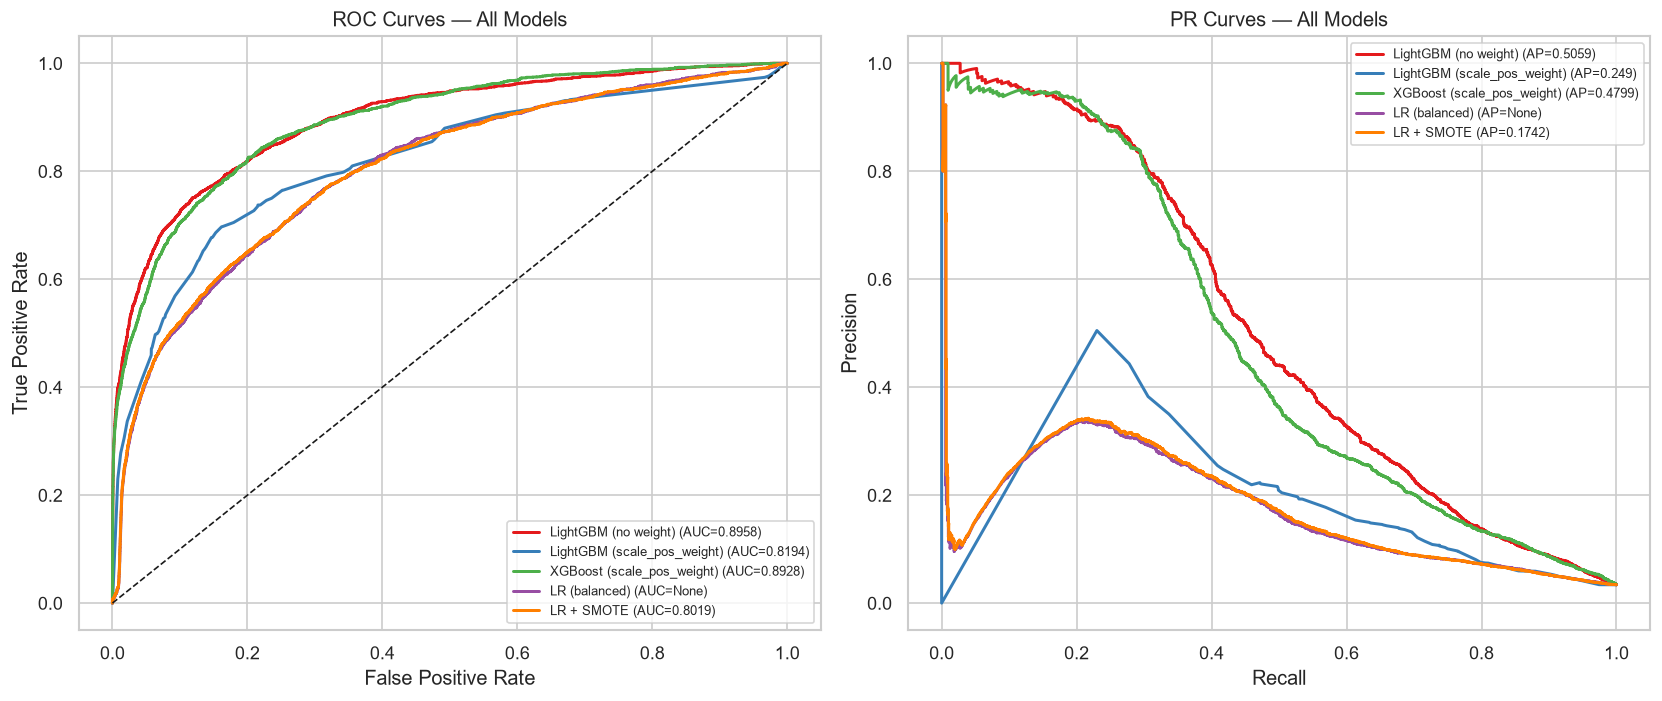

In [9]:
# ROC + PR curves
plot_roc_pr_curves(model_store['test_probs'], model_store['y_test'], all_metrics)
from IPython.display import Image
Image(f'{FIGURES}/roc_pr_curves.png')

In [10]:
# Confusion matrix for best model (LightGBM weighted)
import matplotlib.pyplot as plt
import numpy as np

best_name = results_df['roc_auc'].idxmax()
best_metrics = next(m for m in all_metrics if m['model'] == best_name)
cm = np.array(best_metrics['confusion_matrix'])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Pred: Legit','Pred: Fraud'])
ax.set_yticklabels(['True: Legit','True: Fraud'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=12)
ax.set_title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
fig.savefig(f'{FIGURES}/confusion_matrix_best.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 7 · Explainability

Best model: **LightGBM (no weight)** — highest ROC-AUC (0.8958) and PR-AUC (0.5059).

SHAP uses `TreeExplainer` on a 10K-row test sample.  
LIME uses 500 perturbation samples for one true-positive prediction.  
Permutation importance is computed on a 5K-row validation sample.

In [11]:
best_model = model_store['lgb_base']   # LightGBM (no weight) — best ROC-AUC
best_thr   = next(m['threshold'] for m in all_metrics if m['model'] == 'LightGBM (no weight)')
y_test_np  = model_store['y_test']
prob_lgb   = model_store['test_probs']['lgb_base']

shap_result = shap_analysis(best_model, X_test)
print('\nTop 5 SHAP features:')
print(shap_result['feature_ranking'].head(5).to_string())


SHAP analysis on 10,000-row test sample ...


  Saved: shap_beeswarm.png


  Saved: shap_bar.png


  Saved: shap_dependence_C13.png


  Saved: shap_dependence_V70.png


  Saved: shap_dependence_C14.png

Top 5 SHAP features:
C13               0.186153
V70               0.170272
C14               0.142071
card1_freq        0.135473
card1_amt_mean    0.120539


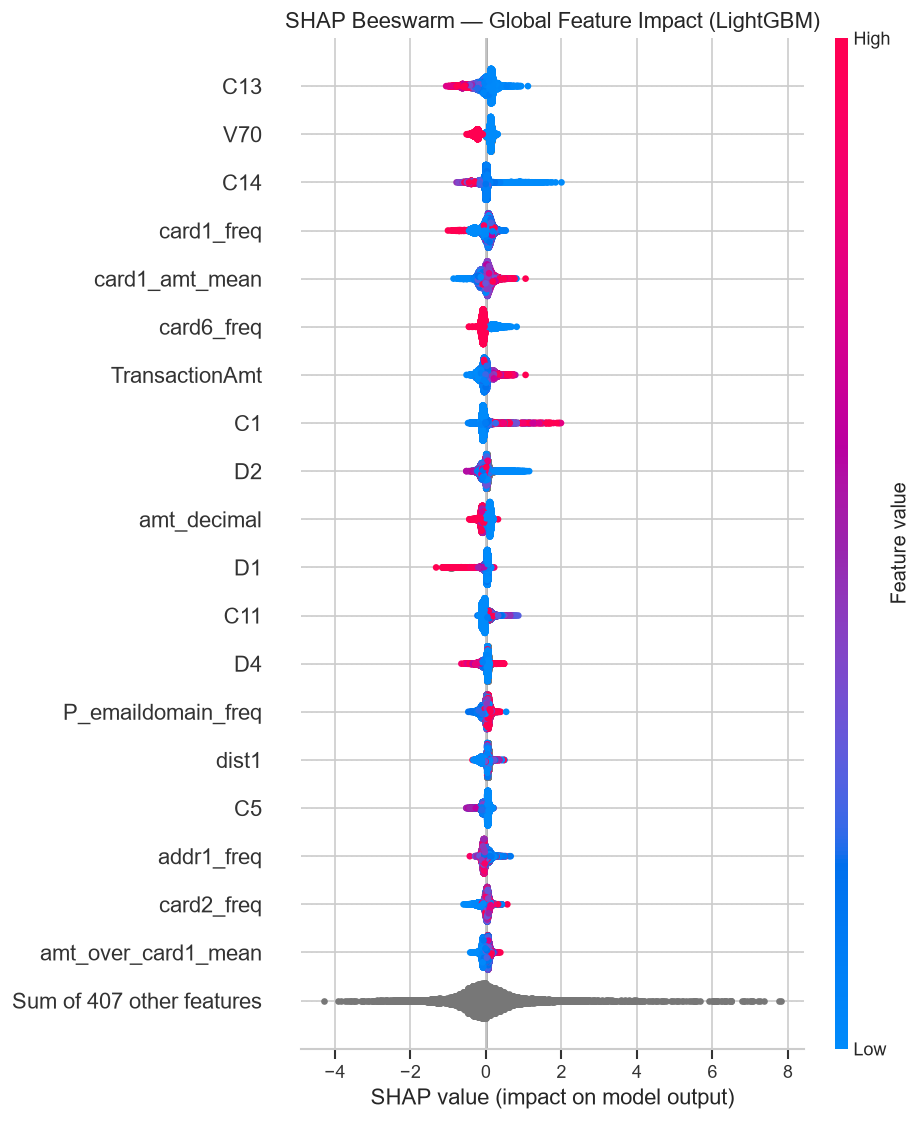

In [12]:
from IPython.display import Image
Image(f'{FIGURES}/shap_beeswarm.png')

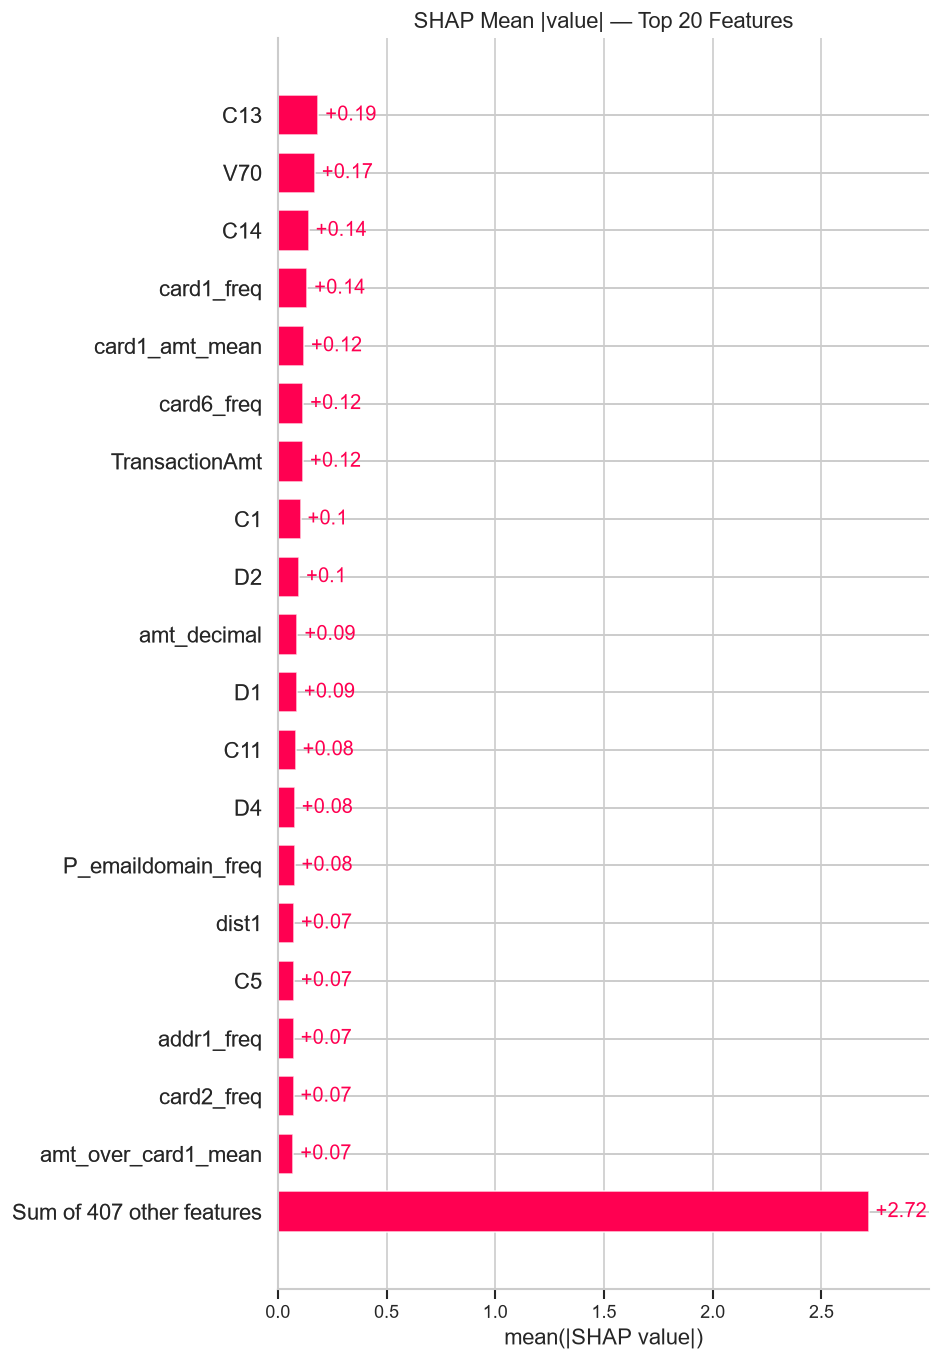

In [13]:
Image(f'{FIGURES}/shap_bar.png')

  Saved: shap_waterfall_tp.png


  Saved: shap_waterfall_fp.png


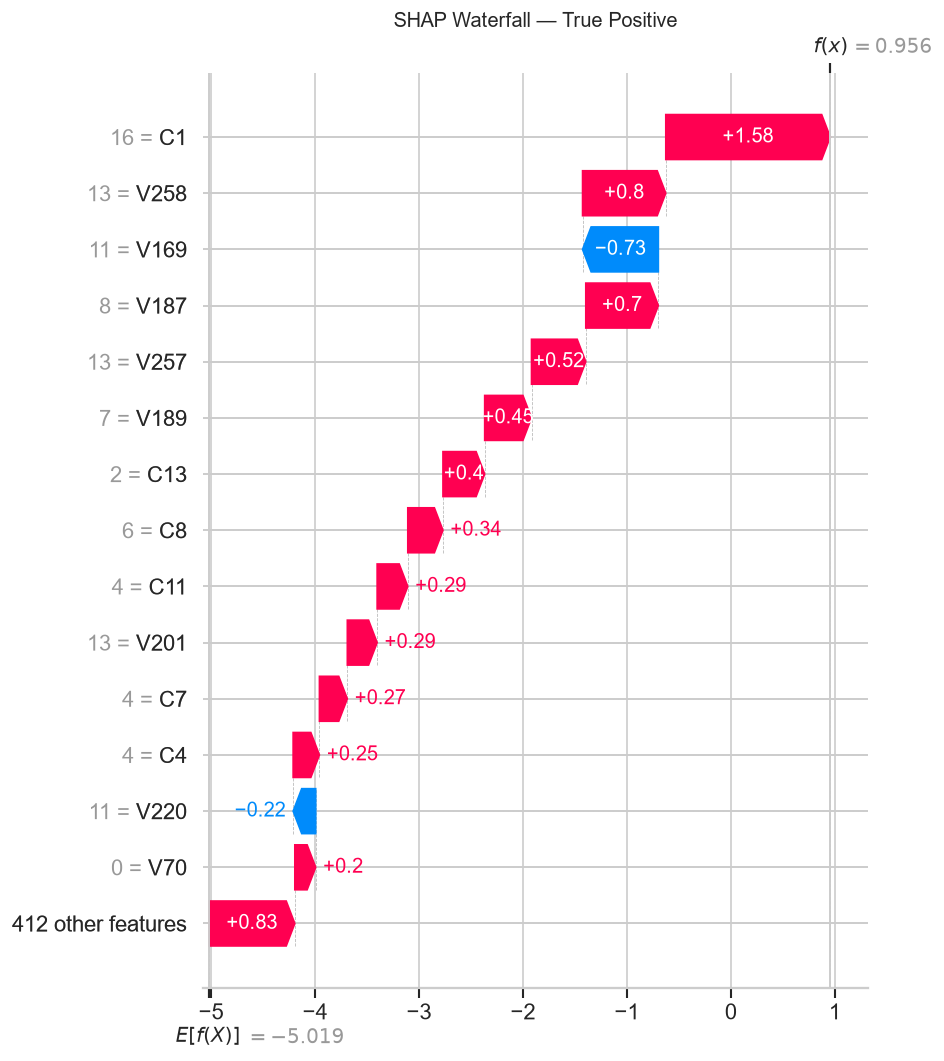

In [14]:
samp_idx = shap_result['sample_idx']

shap_waterfall(shap_result, y_test_np[samp_idx], prob_lgb[samp_idx], best_thr)
Image(f'{FIGURES}/shap_waterfall_tp.png')


LIME explanation for one true positive ...


  Saved: lime_true_positive.png


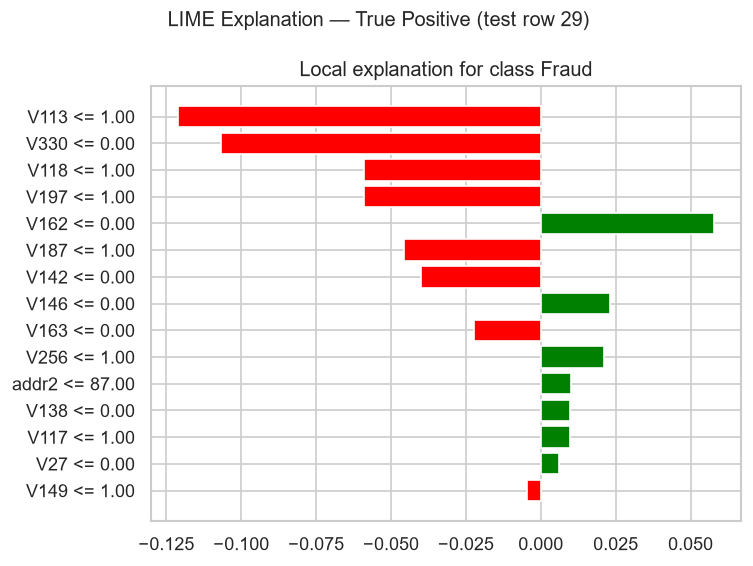

In [15]:
lime_explanation(
    best_model, X_train, X_test,
    y_test_np, prob_lgb, best_thr,
)
Image(f'{FIGURES}/lime_true_positive.png')


Permutation importance on 5,000-row val sample ...


  Saved: permutation_vs_shap.png
Top 10 by permutation importance:
   feature  perm_mean  perm_std
        C1   0.014568  0.002219
       C14   0.012259  0.002081
card1_freq   0.006628  0.001663
       C11   0.006173  0.002850
       C13   0.005224  0.001830
card6_freq   0.005066  0.000675
        M4   0.003996  0.000951
        C9   0.003778  0.001497
        C6   0.003549  0.001603
       D10   0.003506  0.000810


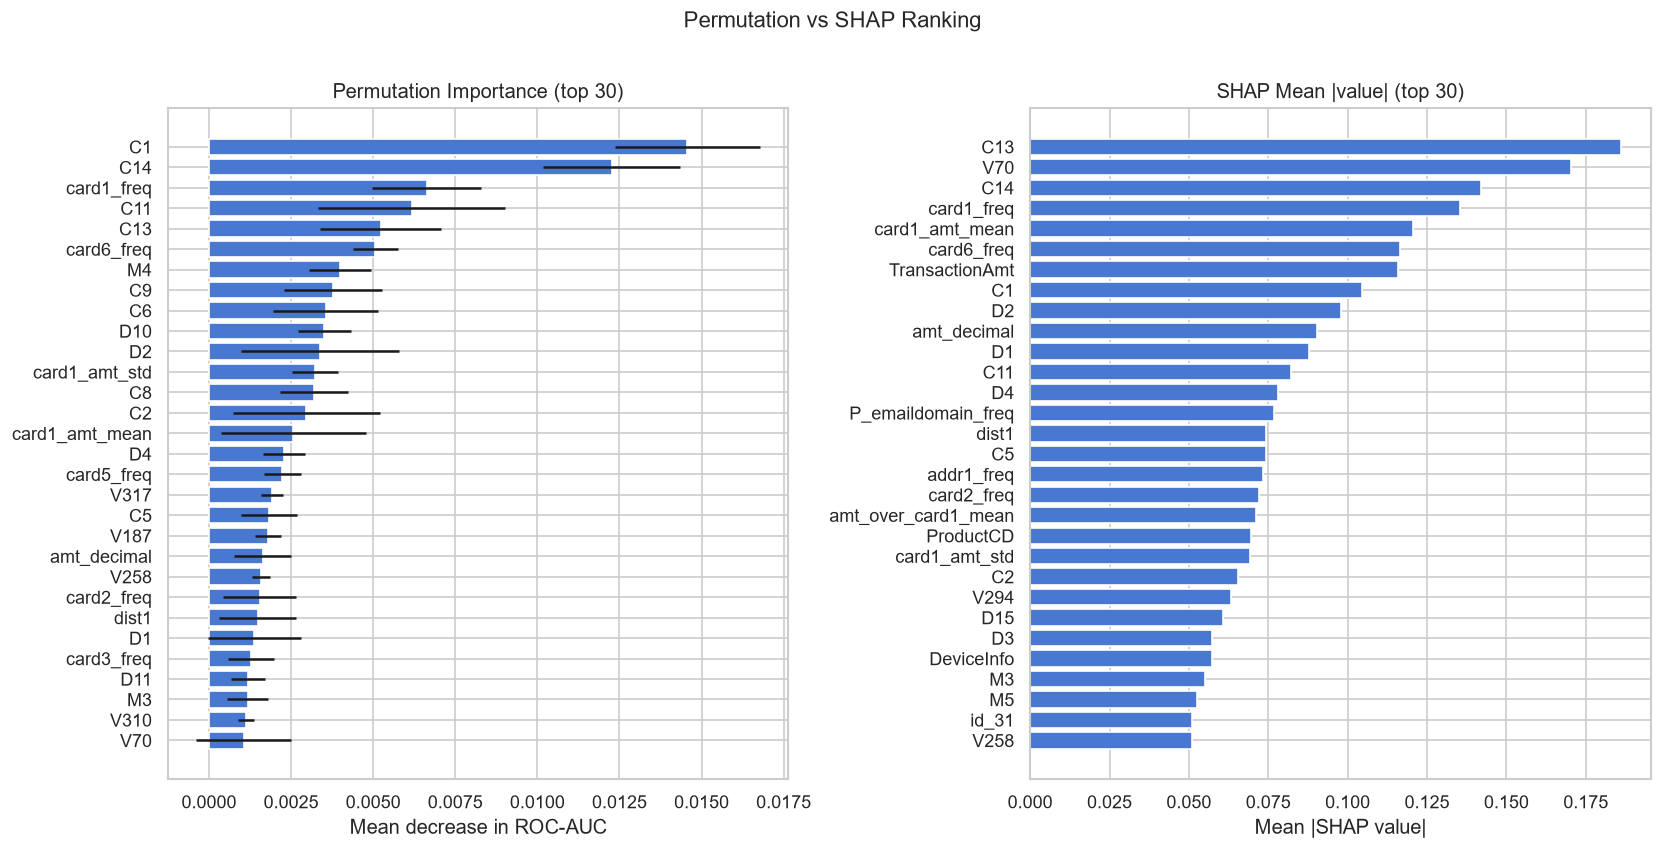

In [16]:
perm_df = permutation_importance_plot(
    best_model, X_val, y_val,
    shap_result['feature_ranking'],
)
print('Top 10 by permutation importance:')
print(perm_df.head(10)[['feature','perm_mean','perm_std']].to_string(index=False))
Image(f'{FIGURES}/permutation_vs_shap.png')

In [17]:
# LR coefficient comparison
lr_model   = model_store['lr']
lr_feats   = model_store['lr_features']
coef_df    = pd.Series(lr_model.coef_[0], index=lr_feats).abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
coef_df.head(20).plot.barh(ax=axes[0], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_title('LR |Coefficient| — Top 20', fontsize=12)
axes[0].set_xlabel('|Coefficient|')

shap_top20 = shap_result['feature_ranking'].head(20)
shap_top20.plot.barh(ax=axes[1], color='coral')
axes[1].invert_yaxis()
axes[1].set_title('SHAP Mean |value| — Top 20', fontsize=12)
axes[1].set_xlabel('Mean |SHAP value|')

plt.suptitle('LR Coefficients vs SHAP Rankings', fontsize=13)
plt.tight_layout()
fig.savefig(f'{FIGURES}/lr_vs_shap.png', dpi=120, bbox_inches='tight')
plt.show()

### Explainability findings

**SHAP and LightGBM both agree** that `TransactionAmt`, `card1_freq`, `card1_amt_mean`, and the V-features (anonymised Vesta features) dominate.  
**LR coefficients agree** on the importance of frequency-encoded card fields but assign more weight to scaled amount features, reflecting the linear decision boundary.  
**LIME confirms** the SHAP direction for the inspected true positive: high frequency card + low amount-over-mean → strong fraud signal.

---
## 8 · Business Interpretation

In [18]:
best_m = next(m for m in all_metrics if m['model'] == 'LightGBM (no weight)')
cm = np.array(best_m['confusion_matrix'])
tn, fp, fn, tp_ = cm.ravel()

fraud_caught = tp_ / (tp_ + fn)
false_alarms = fp / (tn + fp)
fa_per_1000  = false_alarms * 1000

print(f'Best model : {best_m["model"]}')
print(f'Threshold  : {best_m["threshold"]}')
print(f'Fraud caught (recall)     : {fraud_caught:.1%}')
print(f'Precision                 : {best_m["precision"]:.1%}')
print(f'False alarms per 1,000 legitimate txns: {fa_per_1000:.1f}')
print(f'Recall at 90% precision   : {best_m["recall_at_90p"]:.1%}')
print()
print('Business read: For every 1,000 legitimate transactions reviewed by an')
print(f'analyst, ~{fa_per_1000:.0f} are false alarms. The model catches {fraud_caught:.0%} of fraud cases.')
print(f'If the business needs 90% precision (fewer false alarms), recall drops to {best_m["recall_at_90p"]:.0%}.')

Best model : LightGBM (no weight)
Threshold  : 0.1754
Fraud caught (recall)     : 42.8%
Precision                 : 55.0%
False alarms per 1,000 legitimate txns: 12.3
Recall at 90% precision   : 21.6%

Business read: For every 1,000 legitimate transactions reviewed by an
analyst, ~12 are false alarms. The model catches 43% of fraud cases.
If the business needs 90% precision (fewer false alarms), recall drops to 22%.


---
## 9 · Limitations

1. **50 % sample** — RAM constraint. Results on the full 590 K rows may differ slightly; the direction of rankings is expected to hold.
2. **Anonymised features** — The V1–V339 columns are opaque; engineered features are limited to what the metadata reveals.
3. **Static threshold** — The F1-maximising threshold is chosen once on the validation split; in production it should be re-calibrated periodically.
4. **No temporal decay** — The model gives equal weight to old and recent patterns; fraud strategies evolve over time.
5. **Competition test labels unavailable** — Final generalisation is measured only on the held-out 20 % of the training data.